# Testing BaselineGCN with undirected edge GNNdataset

In [1]:
from torch.utils.data import random_split
import numpy as np
import importlib
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("dataset_loader.log"),
        logging.StreamHandler()
    ]
)

In [2]:
from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelTrainer import GNNTrainer
from atoMLtype.models.ModelEncoder import ModelEncoder

encoder = ModelEncoder(collapse=True) # Collapse single/double bond ATs for conjugated systems

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
dataset = GNNdataset(sdf_path, 
                    json_labels, 
                    directed_graph=False,  # Directed edged Turned off
                    labeled=True,           # Labels are present for dataset
                    encoder=encoder) 



[2025-04-22 12:53:14,706] INFO - Enabling RDKit 2024.03.5 jupyter extensions
[2025-04-22 12:53:15,284] INFO - NumExpr defaulting to 10 threads.
[2025-04-22 12:53:15,771] INFO - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-04-22 12:53:15,804] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-22 12:53:15,832] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-22 12:53:15,912] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-22 12:53:15,969] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-22 12:53:16,028] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-22 12:53:16,075] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-04-22 12:53:16,092] WARNING - Atom count mis

FULL DATASET (encoded):


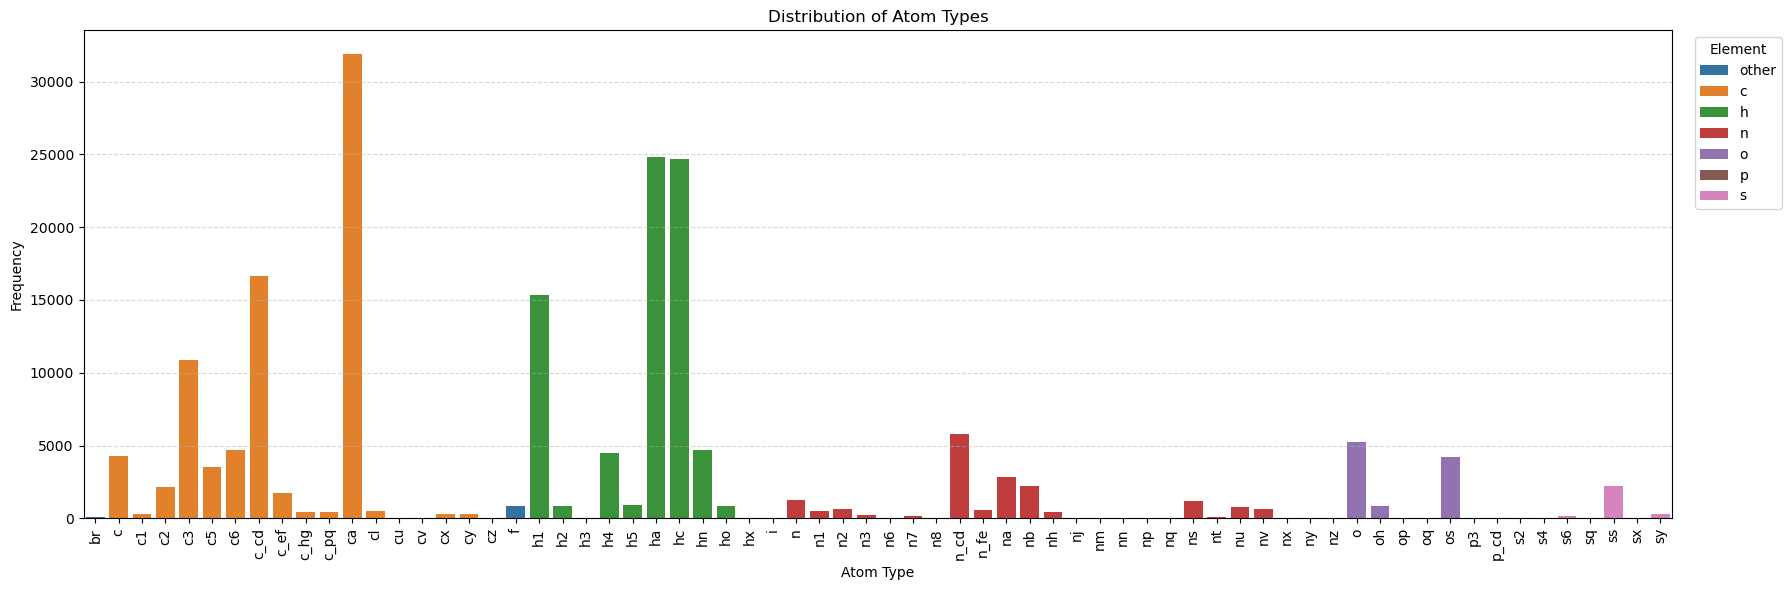

In [5]:
from atoMLtype.analysis.accuracy_counts import plot_atom_distribution


# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(encoder.inverse_transform(dataset.encoded_labels)))



BaselineGCN - Number of parameters: 376900
--- Fold 1/5 ---


Epoch 1: Train Loss = 1.6499, Val Loss = 1.0208
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.6201, Val Loss = 0.6009
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.5344, Val Loss = 0.5194
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.4862, Val Loss = 0.4939
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.4634, Val Loss = 0.4579


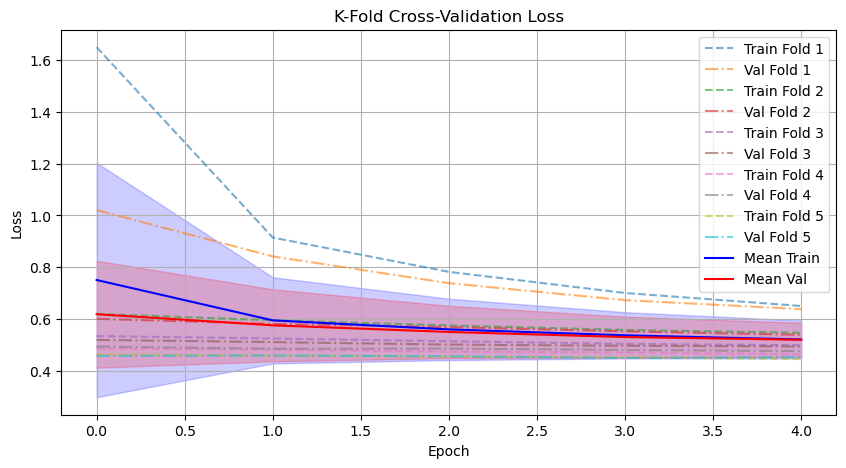

{'train_loss': [[1.6499332665957847,
   0.9147258787260036,
   0.7822274766793398,
   0.7006934934116205,
   0.6504475355916333],
  [0.6200945125152717,
   0.5951306670503309,
   0.575571826612057,
   0.5580341527024563,
   0.5468541838521211],
  [0.5343887621845783,
   0.5247019440110275,
   0.5142524010676026,
   0.5041446619399714,
   0.4988701572570505],
  [0.486239027710052,
   0.4816159979788658,
   0.4743003039311798,
   0.47071384196259414,
   0.46431438039806194],
  [0.46342420298784404,
   0.4587172062629522,
   0.45394061569598965,
   0.45220967384994193,
   0.44541979126618625]],
 'val_loss': [[1.0208201713002059,
   0.842029824421614,
   0.7385668476992381,
   0.6730216323239232,
   0.6384050866689478],
  [0.6008668369244441,
   0.5813333995832692,
   0.5688549007643862,
   0.5525040454558496,
   0.539053247052125],
  [0.5194387888112206,
   0.5109412739279787,
   0.5013240972030258,
   0.49656653633386816,
   0.49385052717622513],
  [0.4938988477248088,
   0.4854053883833

In [6]:
from atoMLtype.models.GNN.BaselineGNNs import BaselineGCN

# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=train_dataset[0].x.shape[1],
                    encoder=encoder, 
                    hidden_dim=512)

trainer = GNNTrainer(model,
                     dataset=train_dataset, 
                     batch_size=32, 
                     learning_rate=0.001,
                      epochs=5, 
                      k_folds=5, 
                      random_seed=21)

trainer.train(verbose=True)

Prediction Summary: 15758/18621 correct (84.62% accuracy)
True label distribution: Counter({'ca': 3310, 'ha': 2534, 'hc': 2336, 'c_cd': 1701, 'h1': 1531, 'c3': 1060, 'n_cd': 613, 'o': 521, 'hn': 493, 'os': 445, 'h4': 441, 'c6': 437, 'c': 397, 'c5': 338, 'na': 303, 'nb': 222, 'ss': 208, 'c2': 194, 'c_ef': 165, 'n': 114, 'ns': 114, 'h5': 104, 'f': 93, 'oh': 83, 'ho': 83, 'h2': 79, 'nu': 78, 'nv': 74, 'n_fe': 60, 'c_hg': 59, 'n1': 55, 'n2': 51, 'cl': 40, 'sy': 34, 'c_pq': 34, 'nh': 33, 'cx': 28, 'n3': 27, 'cy': 25, 'c1': 22, 's6': 22, 'n7': 19, 'nt': 15, 'br': 6, 's4': 4, 'n8': 4, 'cv': 4, 'h3': 3, 'nj': 2, 'sx': 1, 'ny': 1, 'oq': 1})
Pred label distribution: Counter({'ca': 3681, 'ha': 2535, 'hc': 2331, 'c_cd': 1731, 'h1': 1533, 'c3': 1320, 'n_cd': 592, 'o': 519, 'c6': 497, 'hn': 494, 'os': 455, 'h4': 443, 'c5': 438, 'na': 293, 'nb': 271, 'ss': 227, 'c': 173, 'h5': 106, 'f': 93, 'ho': 83, 'h2': 82, 'ns': 76, 'c_hg': 69, 'nv': 60, 'n1': 55, 'oh': 53, 'c2': 50, 'n2': 43, 'cl': 40, 'cx': 36,

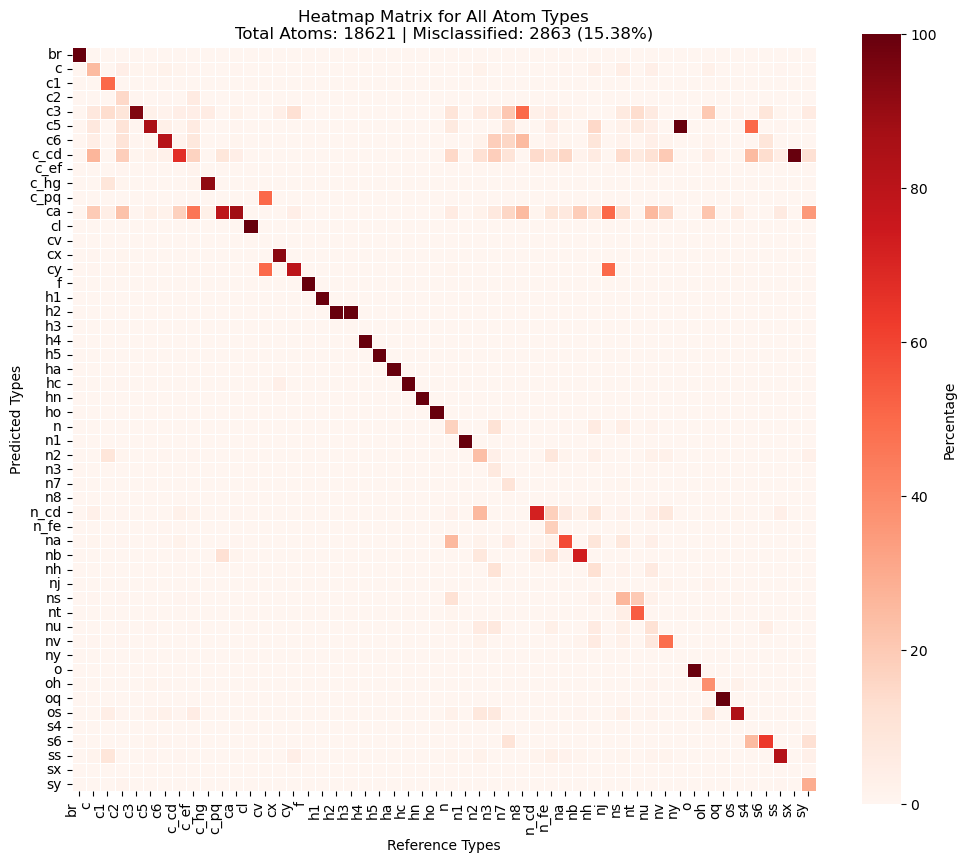

In [7]:
from atoMLtype.models.ModelEngine import ModelEngine
from atoMLtype.analysis.heatmaps import plot_full_heatmap

modelEngine = ModelEngine(model=model, 
                          dataset=test_dataset, 
                          device="cpu", 
                          batch_size=32)

predictionRecord = modelEngine.predict(analysis=False)

predictionRecord.summary()

plot_full_heatmap(predictionRecord)

# Test DMPNN with directed Edge GNNDataset

In [8]:
dirEdge_encoder = ModelEncoder(collapse=True)

# Initialize dataset
dirEdge_dataset = GNNdataset(sdf_path, 
                              json_labels, 
                              directed_graph=True, # Directed edges
                              labeled=True,
                              encoder=dirEdge_encoder)

[2025-04-22 12:57:35,188] INFO - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-04-22 12:57:35,222] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-22 12:57:35,251] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-22 12:57:35,331] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-22 12:57:35,388] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-22 12:57:35,449] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-22 12:57:35,498] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-04-22 12:57:35,517] WARNING - Atom count mismatch for ZINC06661321: 17 atoms in SDF, but 26 labels in JSON.
[2025-04-22 12:57:35,592] WARNING - Atom count mismatch for ZINC17108217: 25 ato

FULL DATASET (encoded):


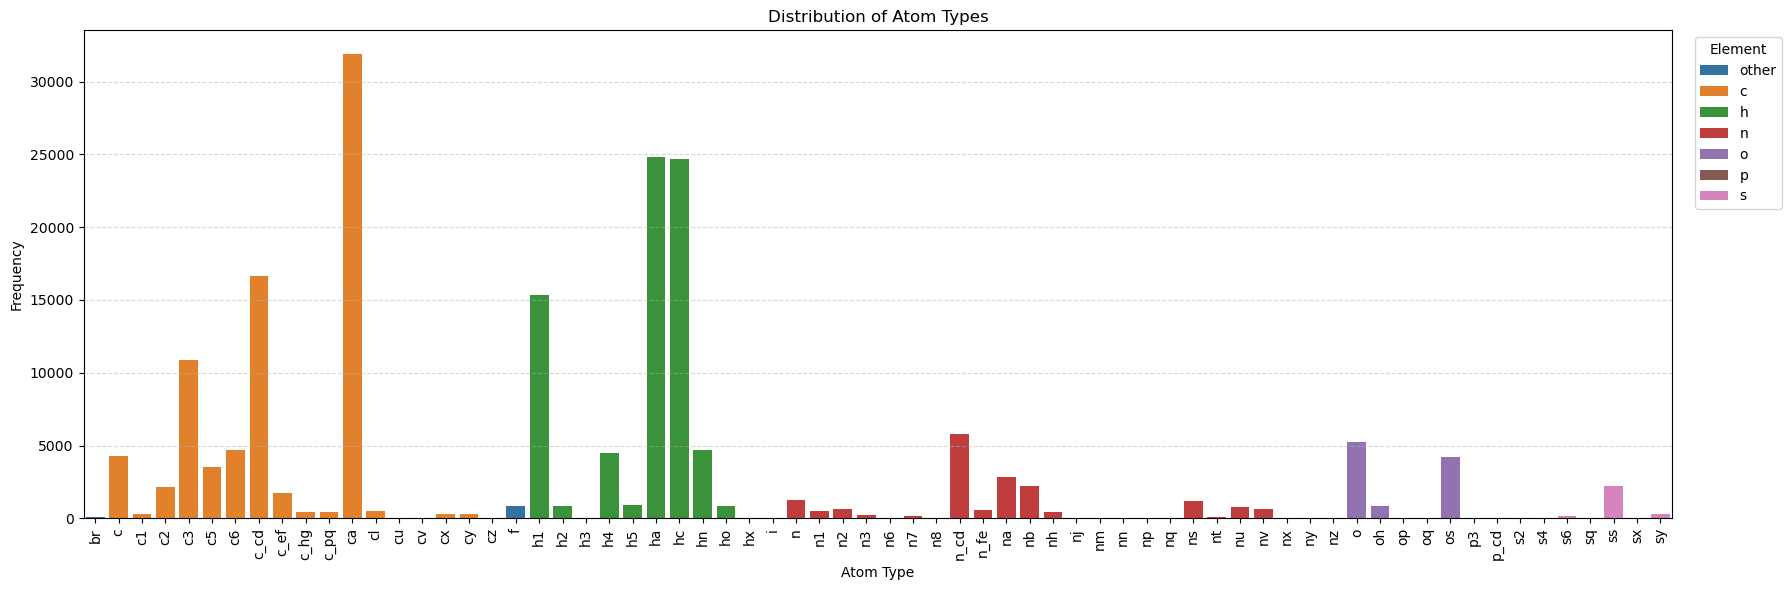

In [9]:
# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(dirEdge_dataset))
test_size = len(dirEdge_dataset) - train_size
train_dataset, test_dataset = random_split(dirEdge_dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(dirEdge_encoder.inverse_transform(dirEdge_dataset.encoded_labels)))

AtomBondMPNN - Number of parameters: 10985550
--- Fold 1/5 ---


Epoch 1: Train Loss = 3.2487, Val Loss = 0.1628
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.1292, Val Loss = 0.0590
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0504, Val Loss = 0.0378
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0390, Val Loss = 0.0366
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0315, Val Loss = 0.0258


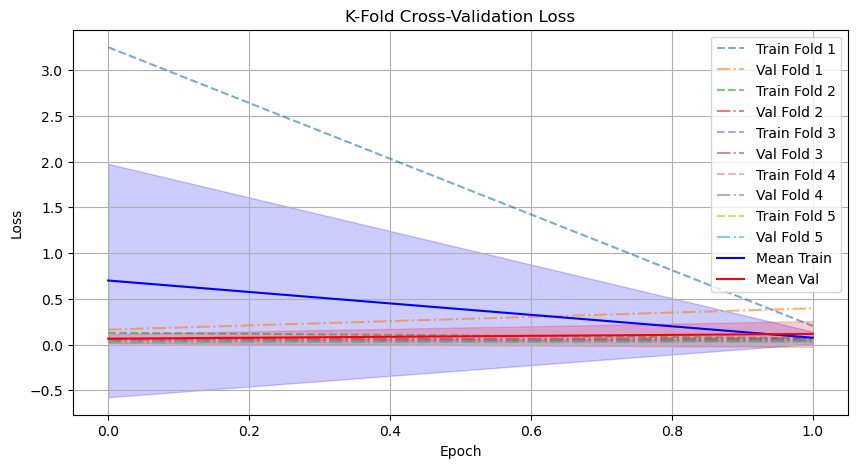

{'train_loss': [[3.248711215968141, 0.20382105078789248],
  [0.12916941342097865, 0.07037694894058588],
  [0.05044178733308064, 0.04195490862995363],
  [0.03904518345459886, 0.03166673146818541],
  [0.03153484283610826, 0.02584538328359814]],
 'val_loss': [[0.16275185072130485, 0.39649288021714113],
  [0.058992339111321165, 0.06613581952350367],
  [0.03775441042812743, 0.046956206968751274],
  [0.03658453841747521, 0.03827990304378905],
  [0.025805572590540726, 0.03279328674533464]]}

In [10]:
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN

# With Attention
model_AtomMPNN_att = AtomBondMPNN(atom_input_dim=dirEdge_dataset[0].x.shape[1], 
                                      bond_input_dim=dirEdge_dataset[0].edge_attr.shape[1], 
                                      hidden_dim=512,
                                      encoder=dirEdge_encoder, 
                                      num_layers=10,
                                      use_attention=True)

trainer_AtomMPNN_att  = GNNTrainer(model_AtomMPNN_att, 
                                   dataset=train_dataset, 
                                   batch_size=32, learning_rate=0.001,
                                   epochs=2, 
                                   k_folds=5, 
                                   random_seed=21)

trainer_AtomMPNN_att.train(verbose=True)

In [11]:
modelEngine_att = ModelEngine(model=model_AtomMPNN_att, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

MPNN_att_record = modelEngine_att.predict(analysis=True)

In [12]:
MPNN_att_record.summary()

Prediction Summary: 18286/18412 correct (99.32% accuracy)
True label distribution: Counter({'ca': 3144, 'ha': 2559, 'hc': 2399, 'c_cd': 1777, 'h1': 1401, 'c3': 1085, 'n_cd': 585, 'o': 548, 'h4': 459, 'hn': 448, 'c': 445, 'os': 399, 'c6': 398, 'c5': 334, 'na': 294, 'c2': 220, 'ss': 209, 'nb': 187, 'c_ef': 167, 'n': 142, 'ns': 123, 'h2': 95, 'f': 90, 'h5': 88, 'n2': 79, 'nu': 75, 'oh': 74, 'ho': 74, 'cl': 63, 'nv': 60, 'n_fe': 58, 'nh': 49, 'n1': 47, 'c_pq': 38, 'c_hg': 38, 'sy': 31, 'cy': 19, 'c1': 18, 'n3': 17, 's6': 17, 'cx': 13, 'nt': 12, 'br': 8, 'n7': 8, 'nm': 3, 'op': 3, 'h3': 3, 'sx': 2, 's4': 2, 'cu': 1, 'i': 1, 's2': 1, 'cv': 1, 'nj': 1})
Pred label distribution: Counter({'ca': 3128, 'ha': 2559, 'hc': 2399, 'c_cd': 1746, 'h1': 1401, 'c3': 1085, 'n_cd': 581, 'o': 548, 'h4': 459, 'hn': 448, 'c': 447, 'os': 399, 'c6': 398, 'c5': 334, 'na': 294, 'c2': 219, 'ss': 210, 'nb': 186, 'c_ef': 178, 'n': 142, 'ns': 123, 'h2': 97, 'f': 91, 'h5': 88, 'n2': 83, 'nu': 76, 'c_pq': 74, 'oh': 74, 

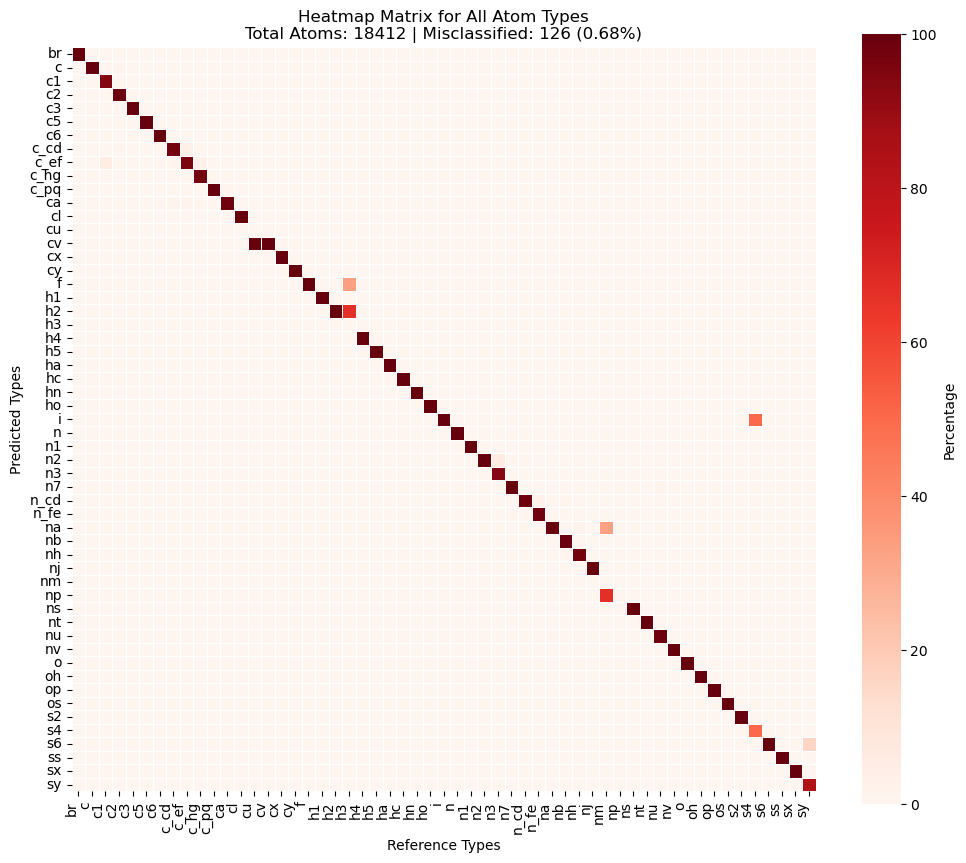

In [13]:
plot_full_heatmap(MPNN_att_record)

# Test Analysis refactoring

## Accuracy_counts

In [17]:
from atoMLtype.analysis.accuracy_counts import get_accuracies_and_counts

accuracie_counts = get_accuracies_and_counts(MPNN_att_record)

for item in accuracie_counts.items():
    print(item[0])
    print(item[1])

accuracy
0.9931566369758853
atom_type_accuracy
{'c3': 1.0, 'c_cd': 0.9752391671356219, 'n_cd': 0.9880341880341881, 'ss': 1.0, 'n3': 0.9411764705882353, 'h1': 1.0, 'ca': 0.986323155216285, 'nb': 0.9893048128342246, 'nh': 0.9795918367346939, 'nv': 1.0, 'hc': 1.0, 'h4': 1.0, 'hn': 1.0, 'os': 1.0, 'f': 1.0, 'n': 1.0, 'c': 1.0, 'o': 1.0, 'c2': 0.990909090909091, 'ha': 1.0, 'h2': 1.0, 'nu': 0.9866666666666667, 'c_pq': 1.0, 'c5': 1.0, 'c_ef': 0.9580838323353293, 'n2': 1.0, 'ns': 1.0, 'oh': 1.0, 'h5': 1.0, 'ho': 1.0, 'na': 0.9931972789115646, 'c6': 1.0, 'c_hg': 0.9736842105263158, 'n1': 1.0, 'n_fe': 0.9827586206896551, 'br': 1.0, 'sx': 1.0, 's6': 1.0, 'sy': 0.8387096774193549, 'nt': 1.0, 'cl': 1.0, 'n7': 1.0, 'c1': 0.9444444444444444, 'nm': 0.0, 'op': 1.0, 'cx': 1.0, 'cu': 0.0, 'cy': 1.0, 's4': 0.5, 'i': 1.0, 's2': 1.0, 'h3': 0.0, 'cv': 1.0, 'nj': 1.0}
atom_type_counts
{'c3': 1085, 'c_cd': 1777, 'n_cd': 585, 'ss': 209, 'n3': 17, 'h1': 1401, 'ca': 3144, 'nb': 187, 'nh': 49, 'nv': 60, 'hc': 2399

## ConfusionMatrices

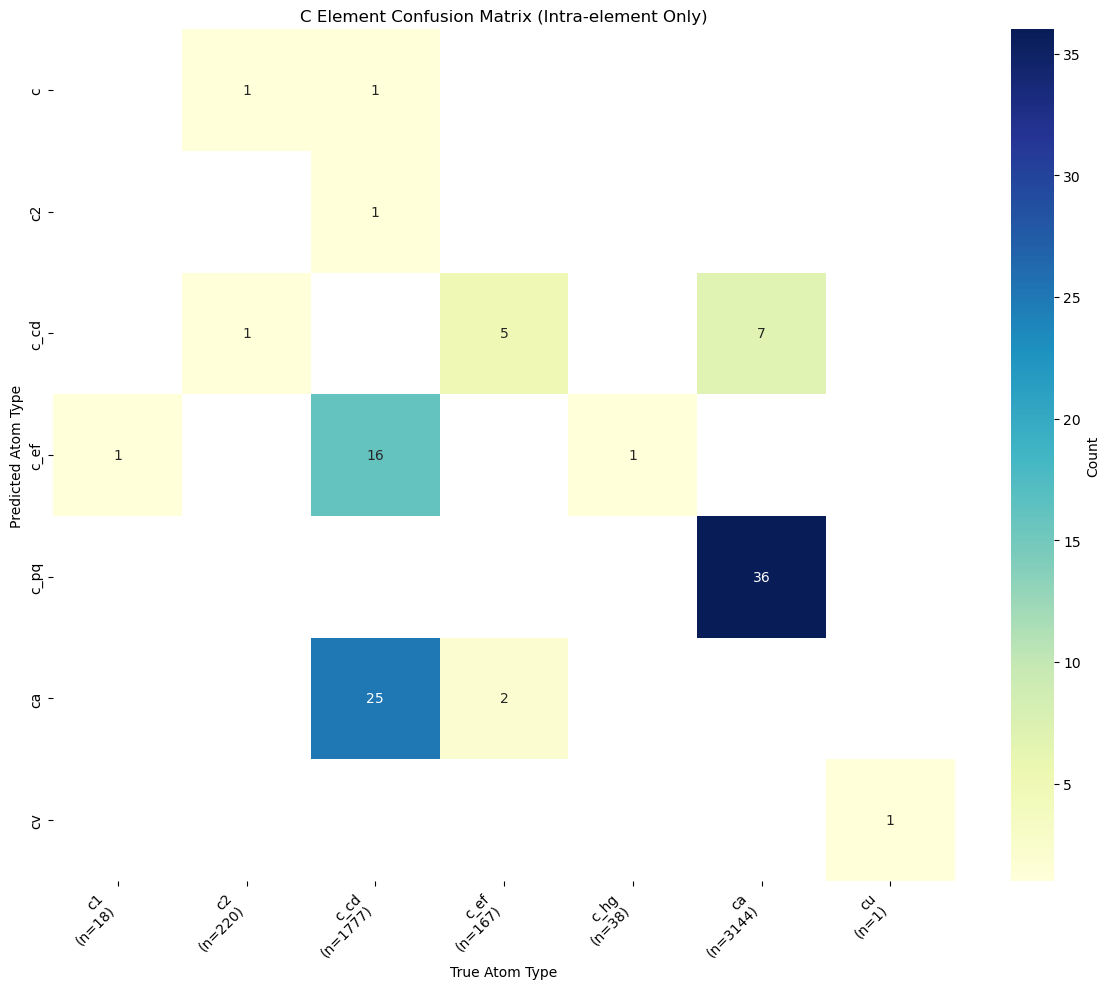

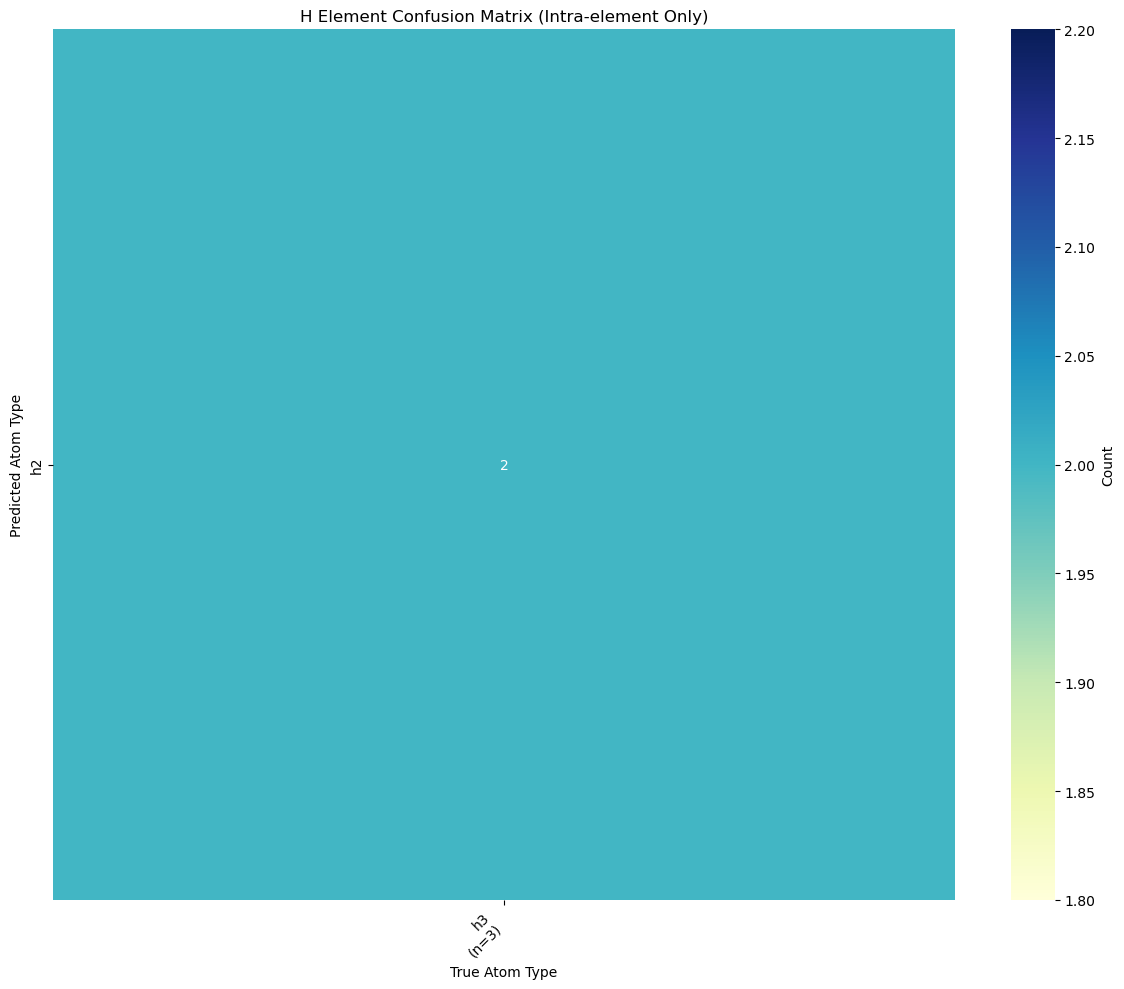

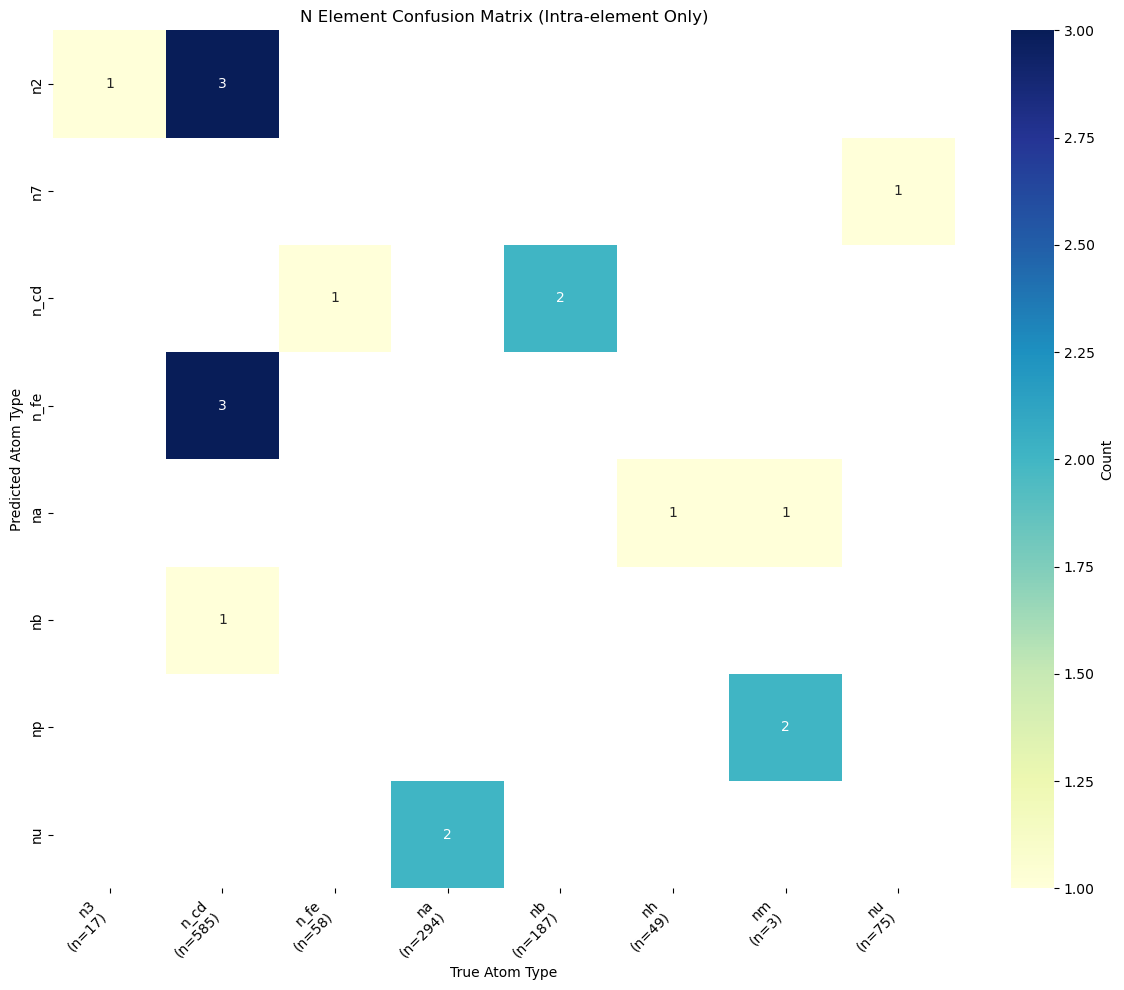

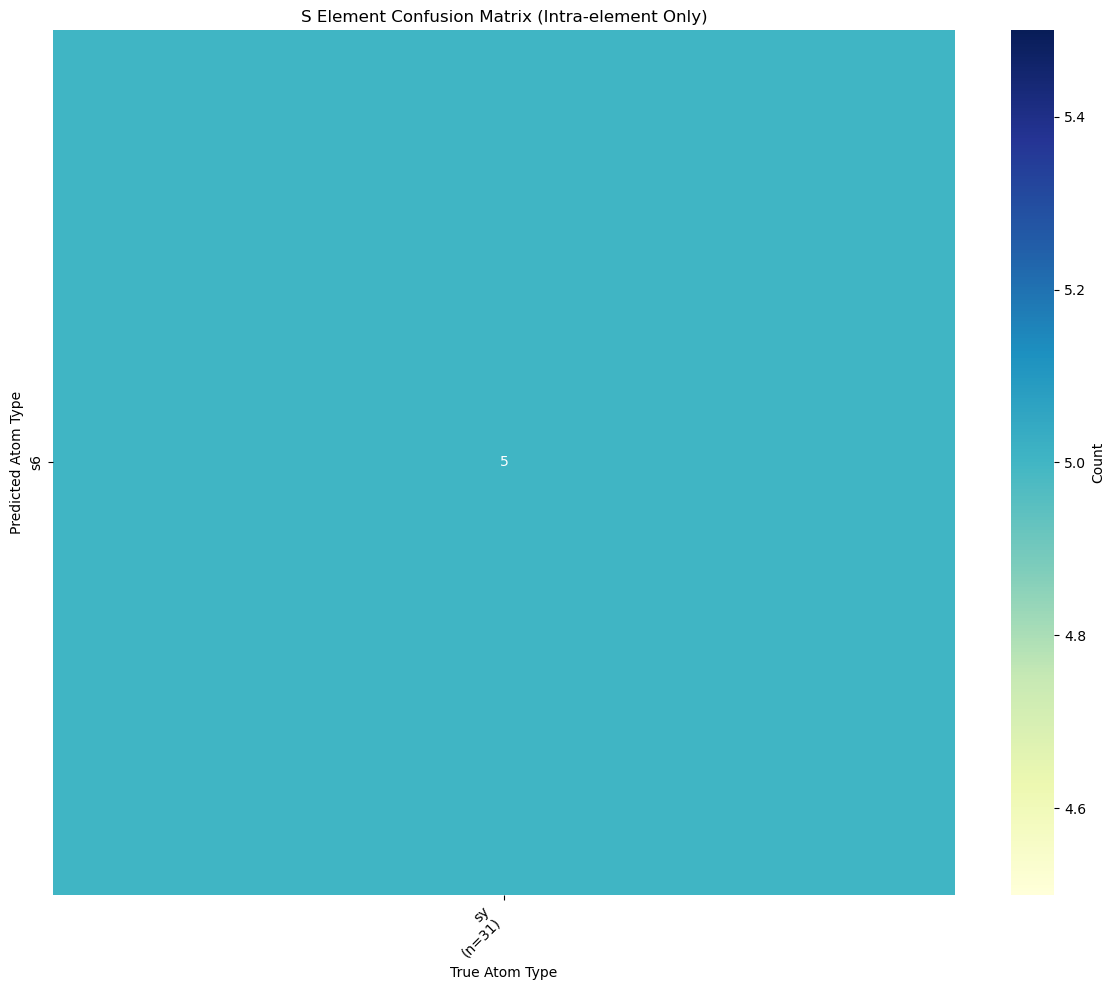

In [18]:
from atoMLtype.analysis.confusionMatrices import plot_full_confusion_matrices, plot_element_confusion_matrices

plot_element_confusion_matrices(MPNN_att_record)


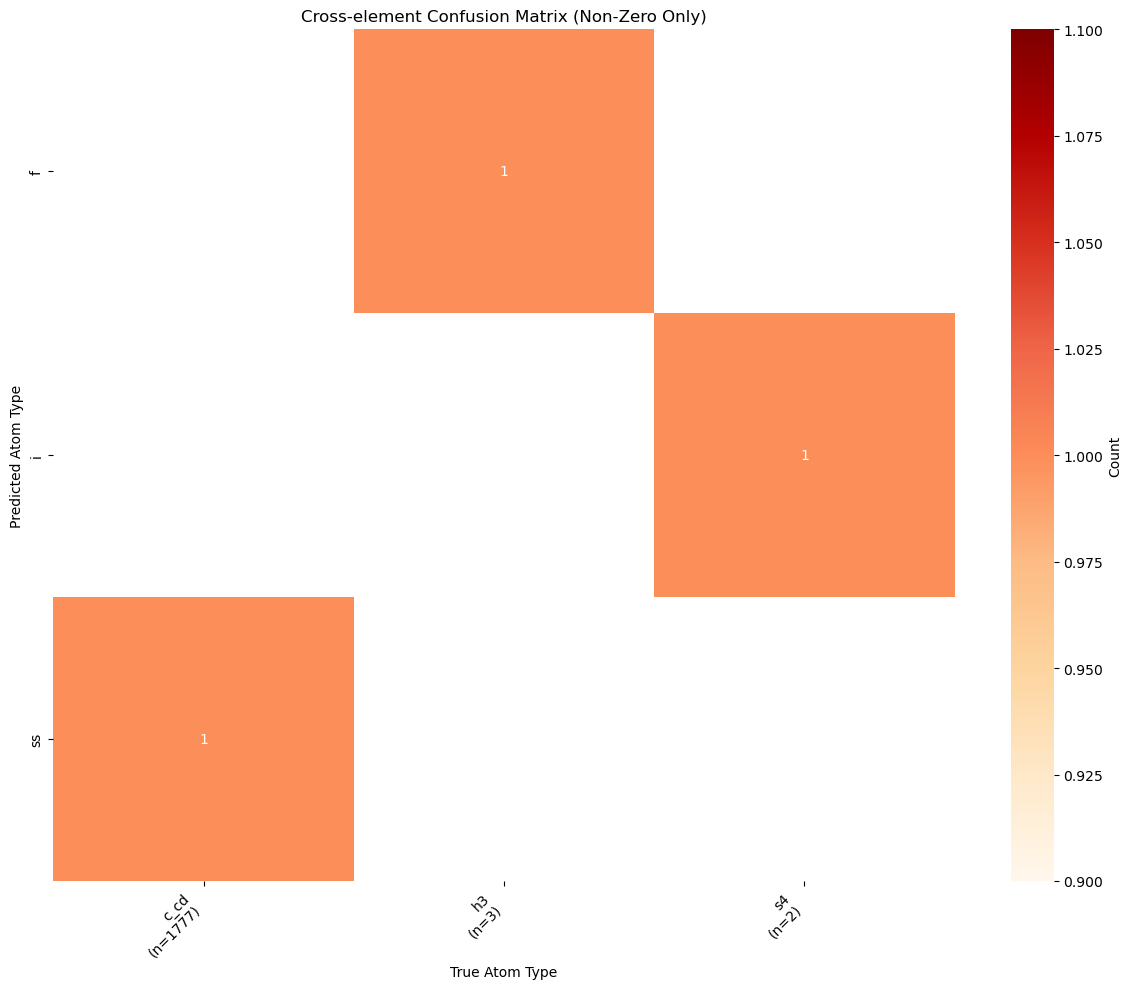

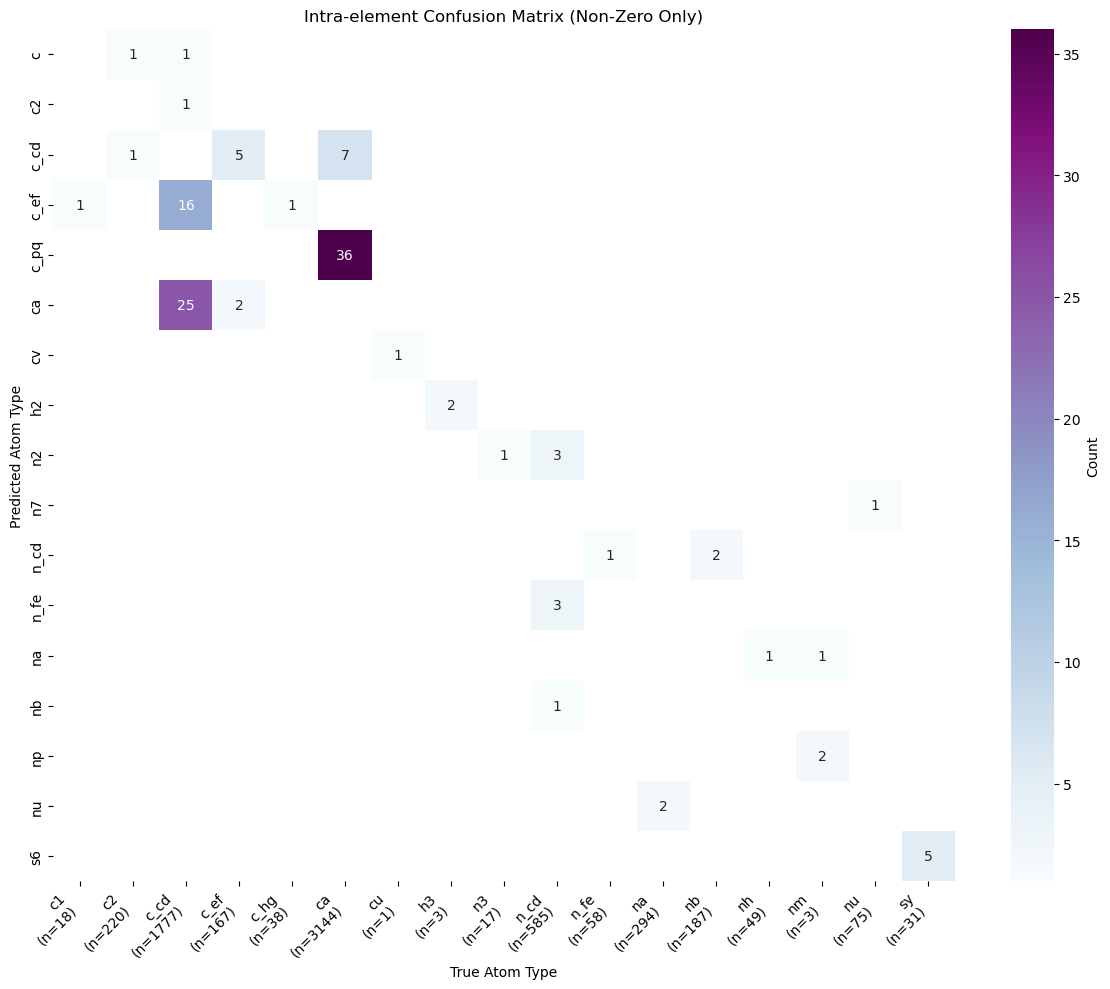

In [19]:
plot_full_confusion_matrices(MPNN_att_record)

## Discrepancies

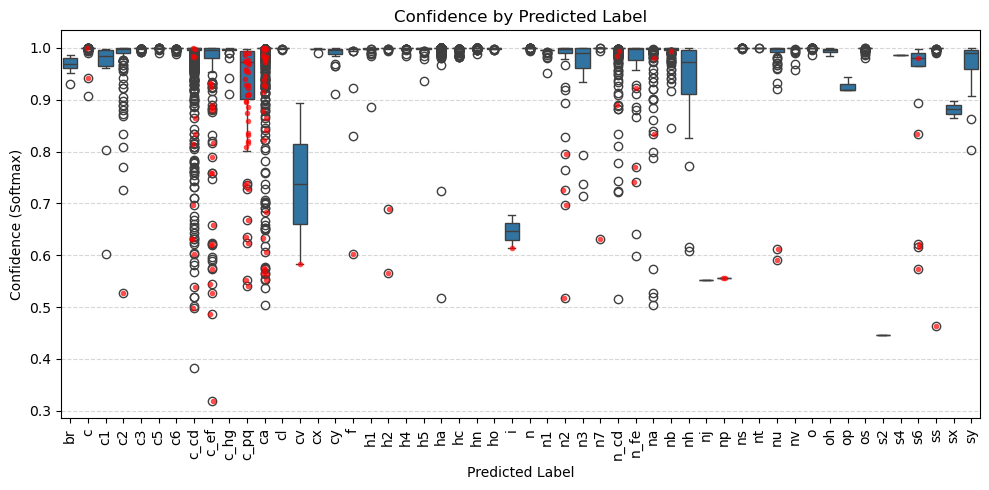

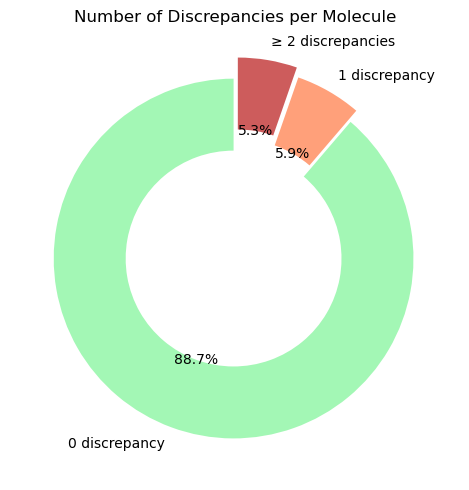

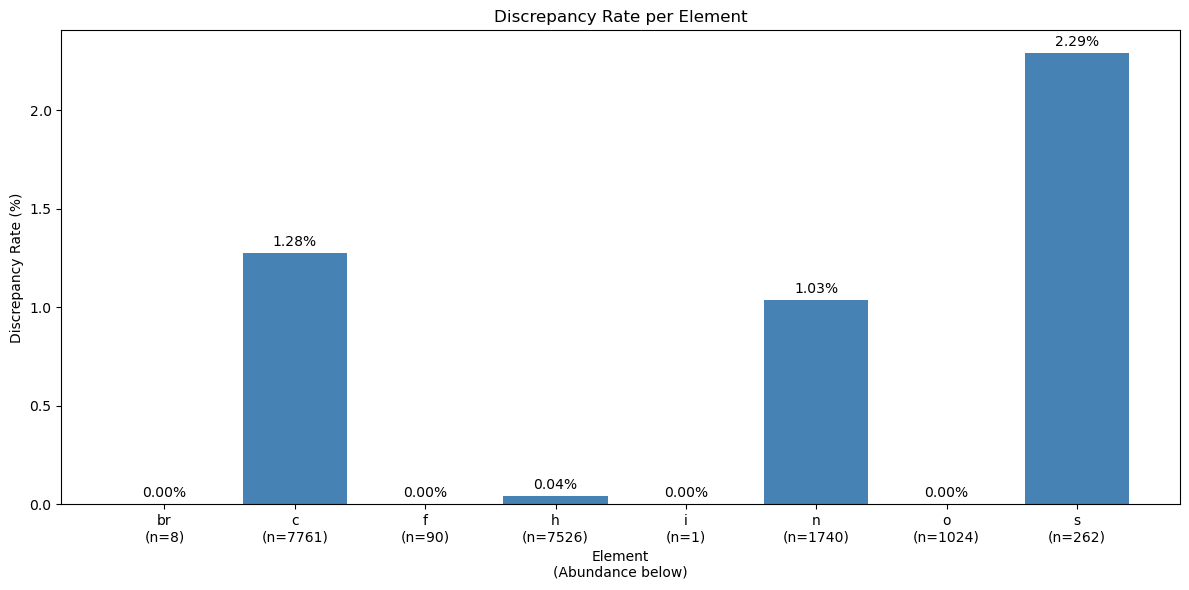

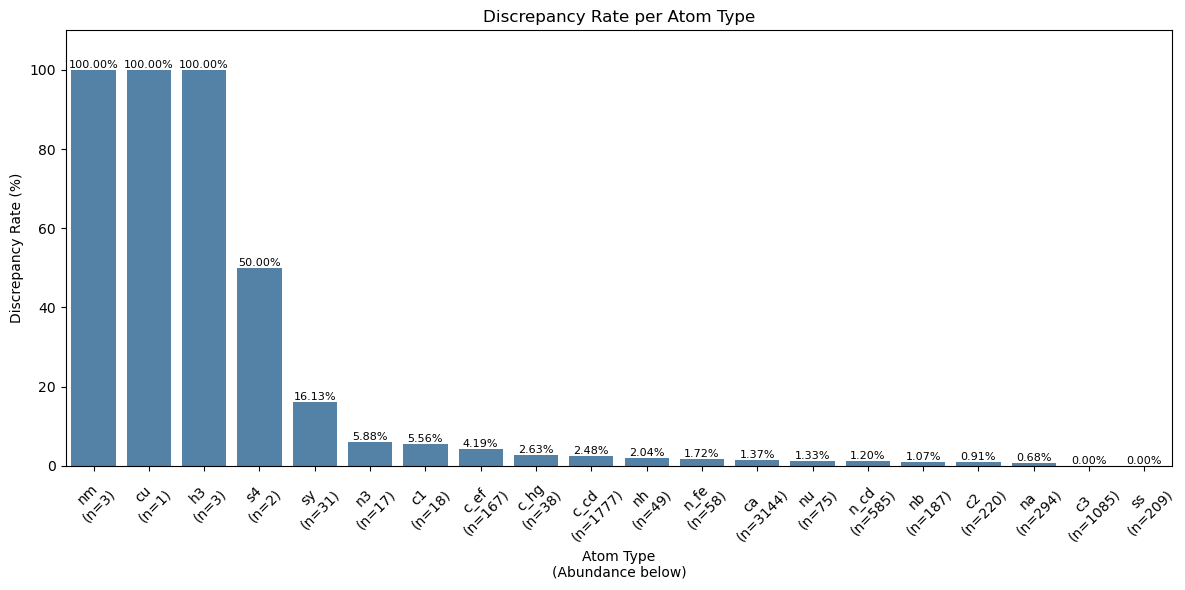

In [21]:
from atoMLtype.analysis.discrepancies import plot_confidence_by_pred_label, plot_discrepancy_distribution, plot_element_discrepancy_rate, plot_discrepancy_rate_by_atom_type

plot_confidence_by_pred_label(MPNN_att_record, 
                              sort_by='alphabetical',
                              show_mismatch=True,
                              showfliers=True, 
                              figsize=(10, 5))

plot_discrepancy_distribution(MPNN_att_record)


valid_elements = {
        "f", "cl", "br", "i", "c", "h", "n", "o", "s", "p"
    }

plot_element_discrepancy_rate(MPNN_att_record, valid_elements)

plot_discrepancy_rate_by_atom_type(MPNN_att_record)

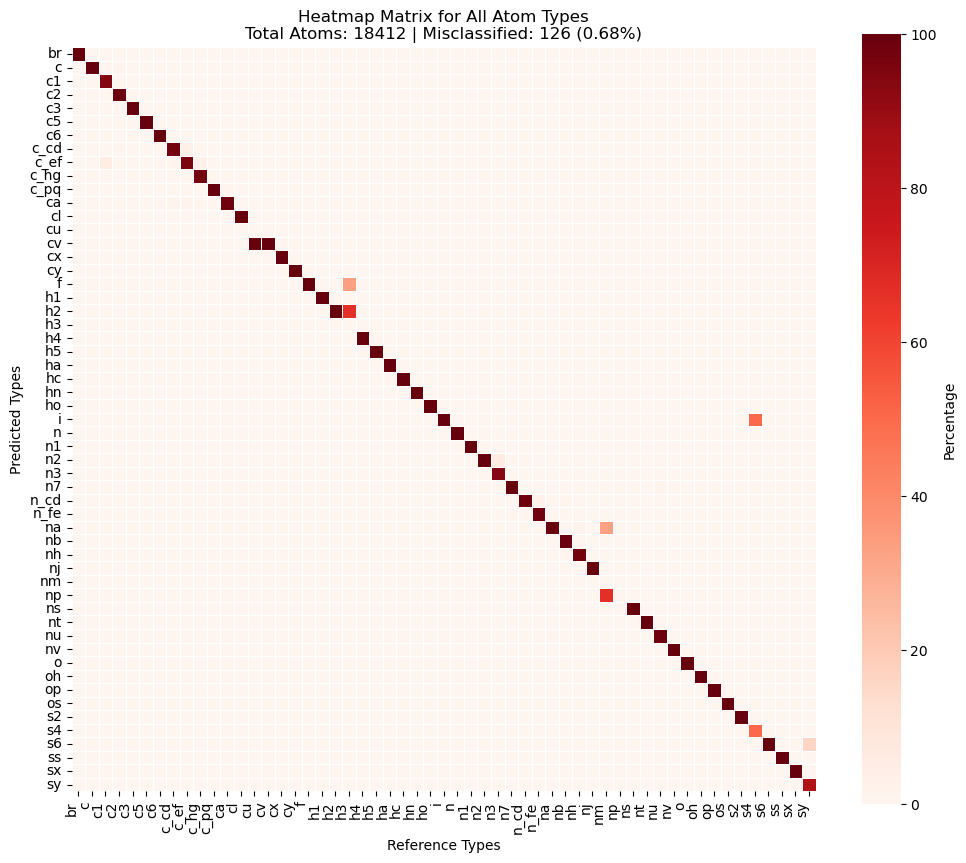

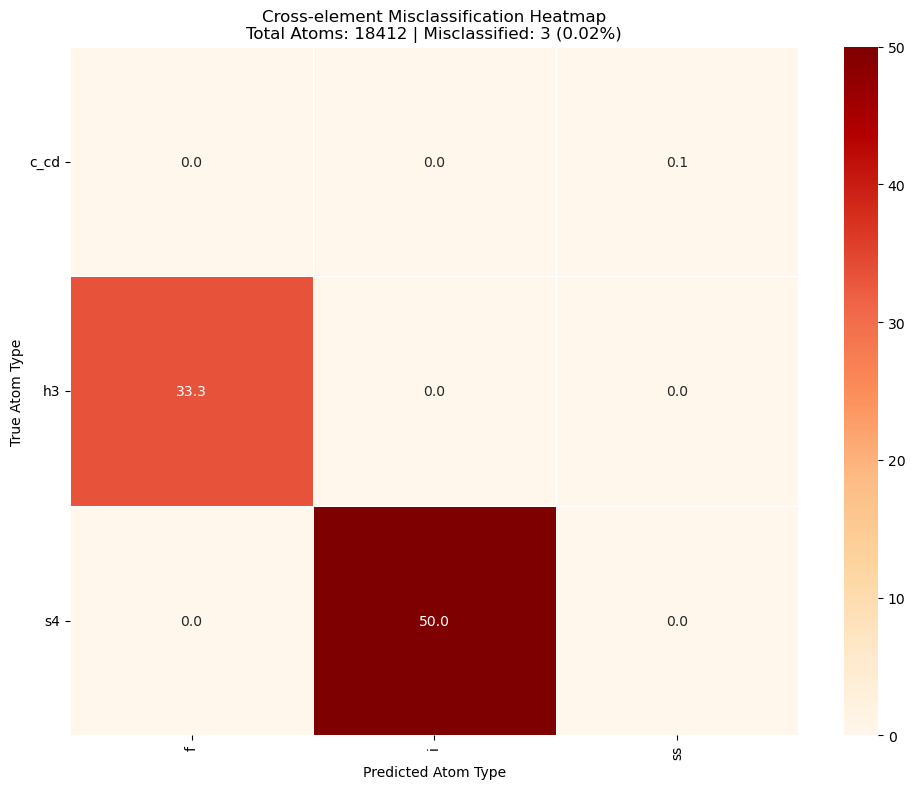

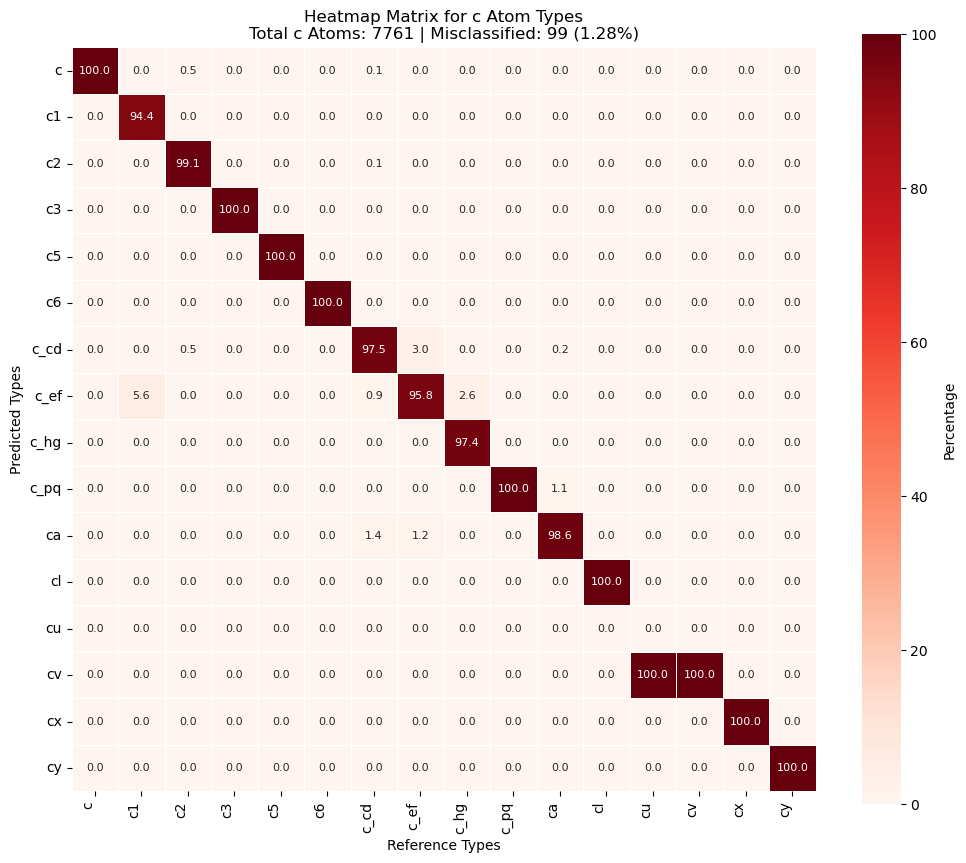

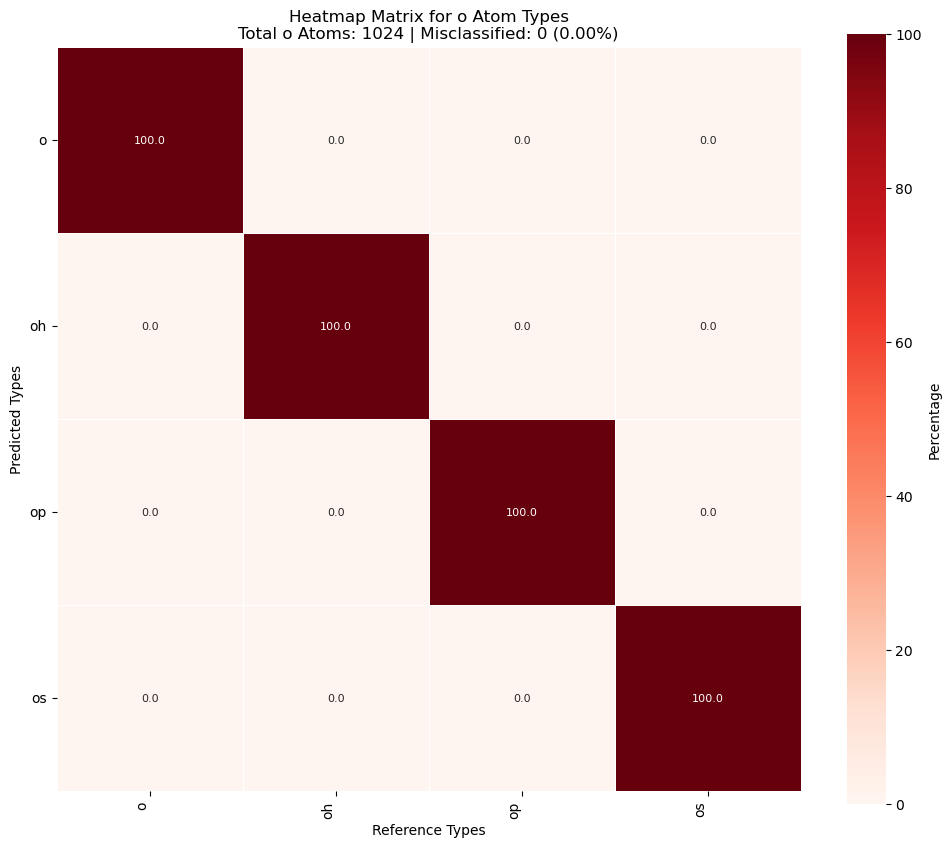

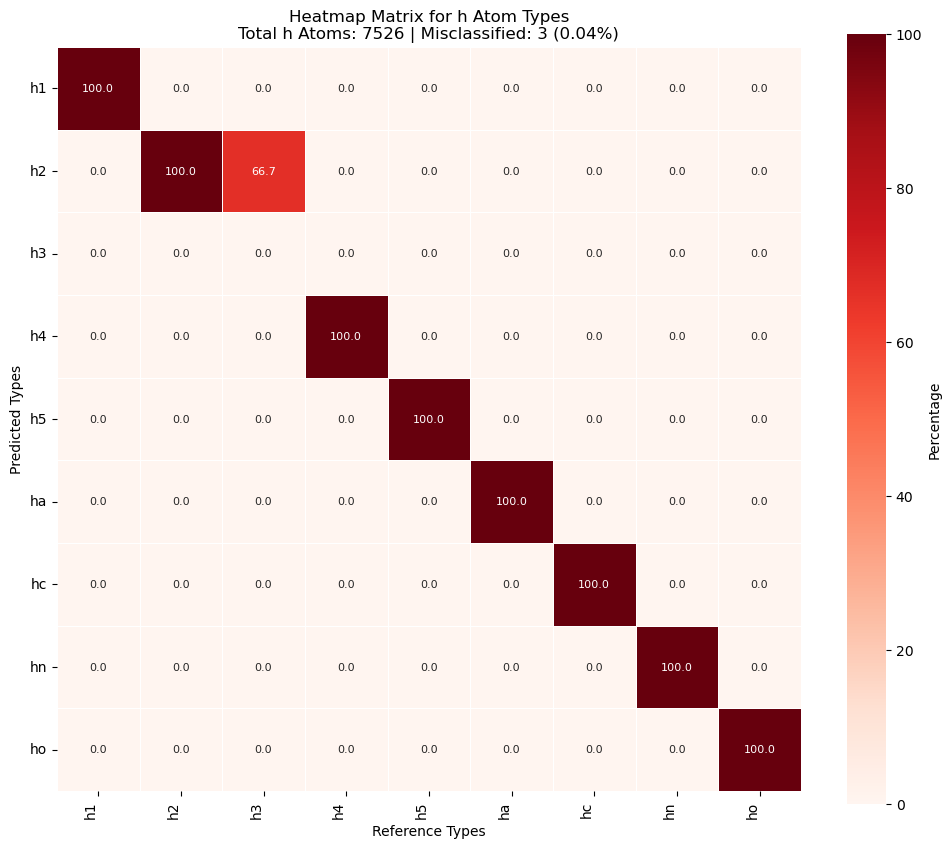

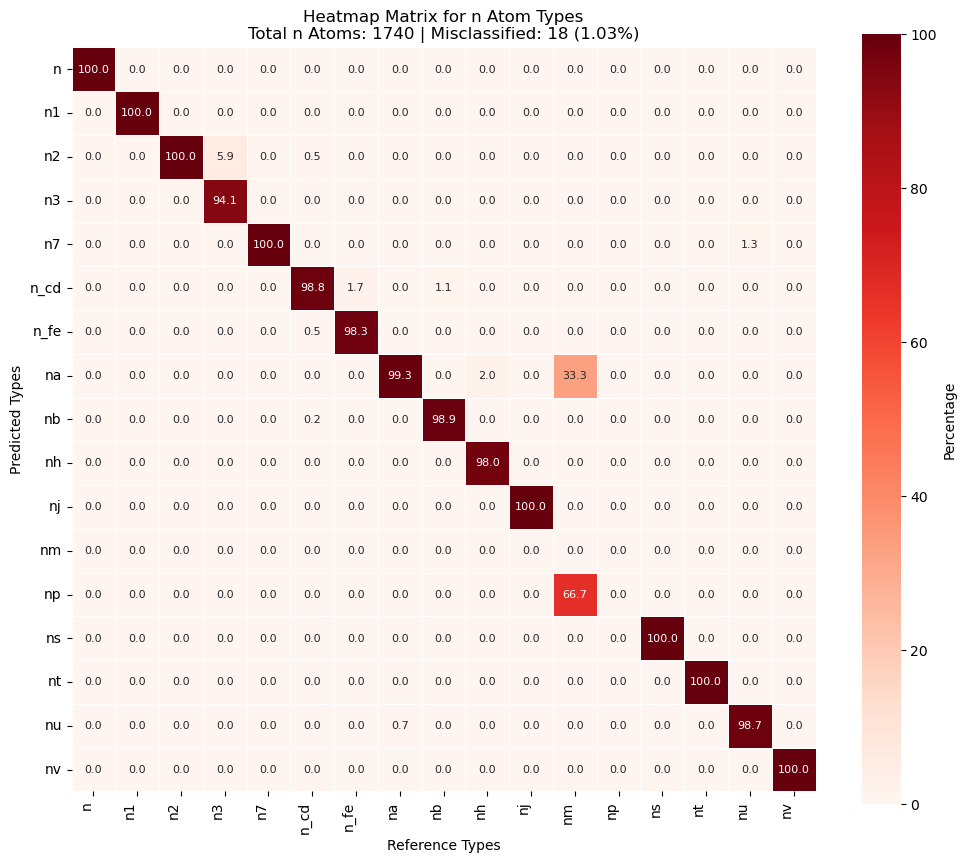

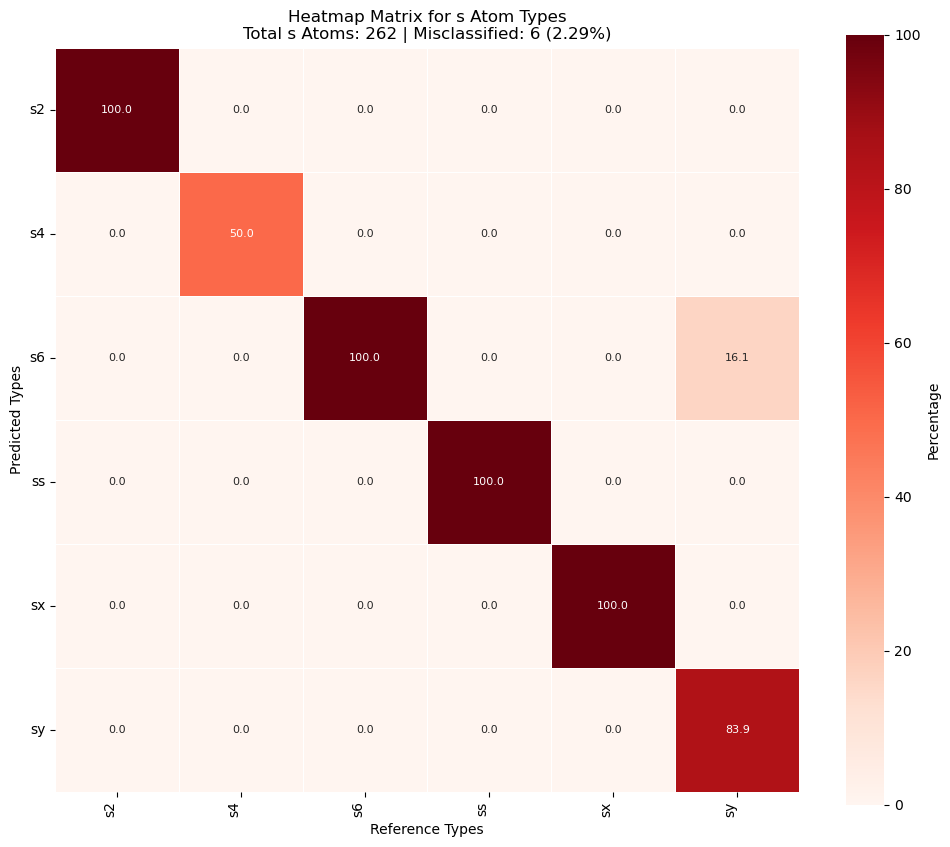

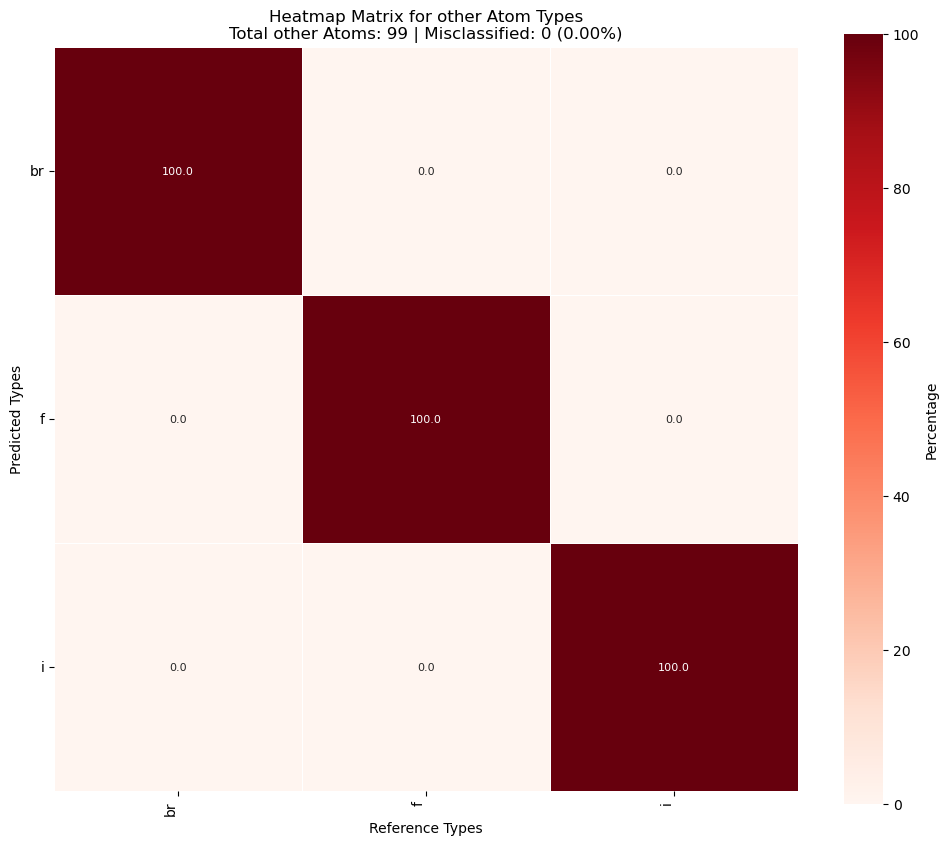

In [22]:
from atoMLtype.analysis.heatmaps import plot_full_heatmap, plot_cross_element_heatmap, plot_element_heatmap

plot_full_heatmap(MPNN_att_record)

plot_cross_element_heatmap(MPNN_att_record)

plot_element_heatmap(MPNN_att_record)

## Molecule_embeddings

/Users/brobello/Capstone_biovia/Biovia-1/atoMLtype/analysis/molecule_embeddings.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


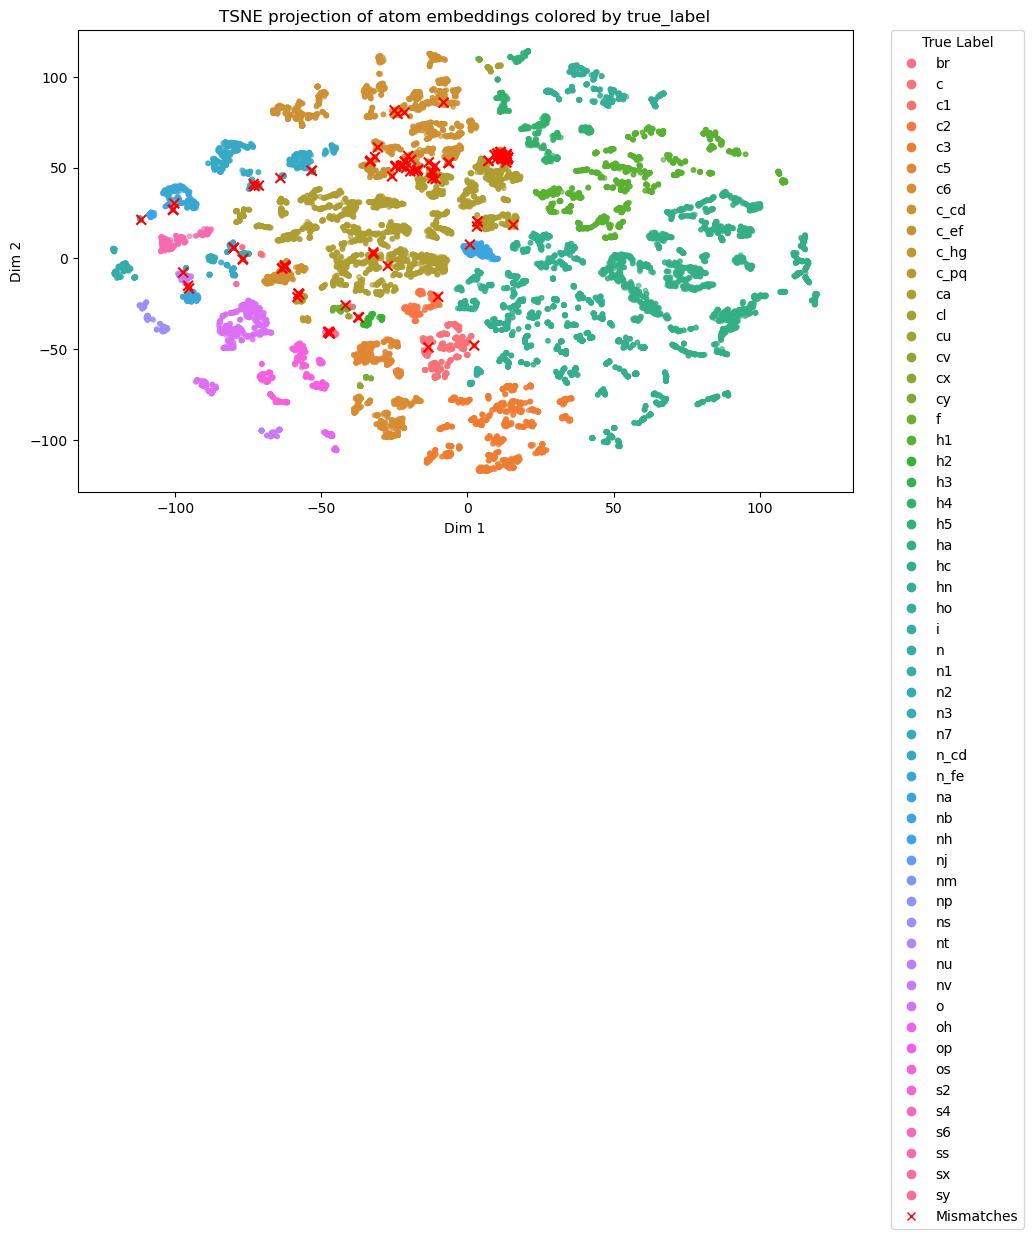

In [23]:

from atoMLtype.analysis.molecule_embeddings import visualize_prediction_embeddings

visualize_prediction_embeddings(
    pred_record=MPNN_att_record,
    key='clf_embeddings',
    method='tsne'
)

ZINC01008900 atom 5, pred AT c_pq for ca
ZINC01008900 atom 6, pred AT c_pq for ca


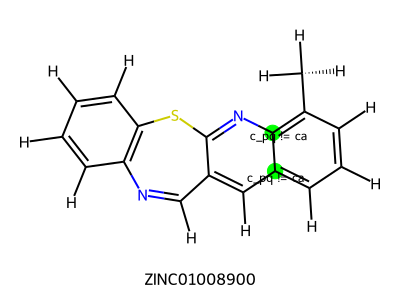

ZINC13443384 atom 3, pred AT ca for c_ef
ZINC13443384 atom 4, pred AT ca for c_ef
ZINC13443384 atom 9, pred AT c_pq for ca


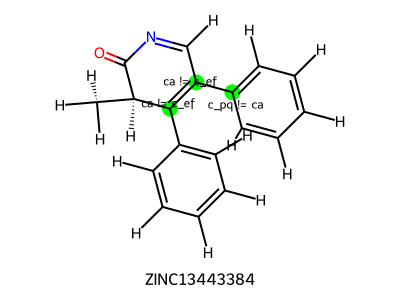

ZINC01682796 atom 3, pred AT c_pq for ca
ZINC01682796 atom 4, pred AT c_pq for ca


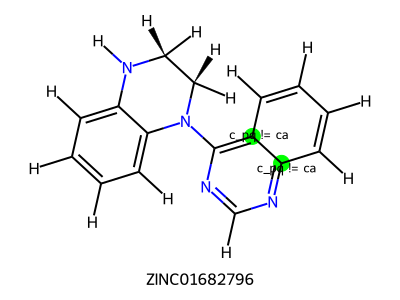

ZINC00334889 atom 4, pred AT c_pq for ca
ZINC00334889 atom 6, pred AT c_pq for ca


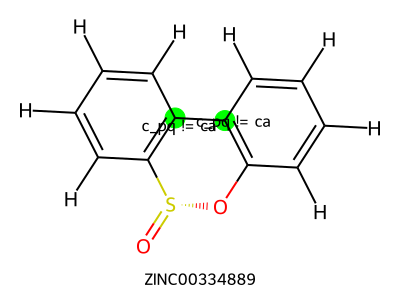

ZINC05606300 atom 6, pred AT n2 for n3


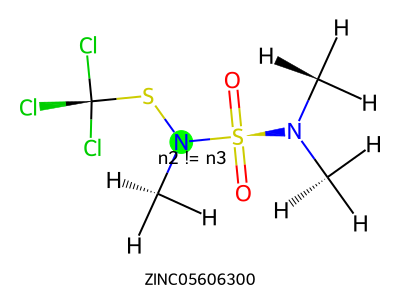

ZINC03267757 atom 3, pred AT c_pq for ca
ZINC03267757 atom 4, pred AT c_pq for ca


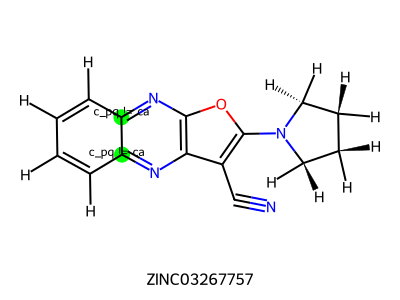

In [34]:
import atoMLtype.analysis.molecule_embeddings 
importlib.reload(atoMLtype.analysis.molecule_embeddings)
from atoMLtype.analysis.molecule_embeddings import draw_molecule_with_mismatches_labeled


mismatched_mols = MPNN_att_record.mismatched_molecules
original_dataset = getattr(test_dataset, 'dataset', test_dataset)

max = 5
count = 0

for mol_name, atom_preds in mismatched_mols.items():
    if count > max:
        break
    count += 1
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol = original_dataset.get_mol(mol_name)

    img = draw_molecule_with_mismatches_labeled(mol, atom_preds)
    display(img)  # or img.save(f"{mol_name}_mismatch.png")